# 02 — Physics Baseline (pvlib)

Consumes `data/processed/unified_2018_661.parquet` produced by `01_data_pipeline.ipynb`.

**Goal:** compute what the panels *should* produce each hour from solar physics alone,
add it as `physics_predicted_pv` to the unified frame, and quantify the gap vs. actual yield.
That gap is the signal Week 3 ML will learn to correct.

**Task sequence:**
- 2.1 Load artifact + system definition (location, array geometry, capacity)
- 2.2 Solar position & clear-sky reference
- 2.3 GHI → POA irradiance (Erbs decomposition + transposition)
- 2.4 POA → predicted AC power (PVWatts)
- 2.5 Comparison: physics vs. actual (RMSE/MAE + plot)

In [1]:
import pandas as pd
import numpy as np
import pvlib
from pathlib import Path

## Task 2.1 — Load artifact & system definition

In [2]:
unified = pd.read_parquet(Path("../data/processed/unified_2018_661.parquet"))

assert unified.index.tz is not None,             "Index must be tz-aware UTC"
assert not unified.index.has_duplicates,         "Duplicate timestamps"
assert unified.index.is_monotonic_increasing,    "Index not sorted"
assert len(unified) == 8760,                     "Expected 8760 hourly rows for 2018"

print(unified.info())
print(f"\nNaNs: {unified.isna().sum().to_dict()}")

<class 'pandas.DataFrame'>
DatetimeIndex: 8760 entries, 2018-01-01 00:00:00+00:00 to 2018-12-31 23:00:00+00:00
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   temperature_2m        8760 non-null   float64
 1   shortwave_radiation   8760 non-null   float64
 2   household_load_kwh    8724 non-null   float64
 3   actual_pv_yield_kwh   8669 non-null   float64
 4   physics_predicted_pv  8760 non-null   float64
dtypes: float64(5)
memory usage: 410.6 KB
None

NaNs: {'temperature_2m': 0, 'shortwave_radiation': 0, 'household_load_kwh': 36, 'actual_pv_yield_kwh': 91, 'physics_predicted_pv': 0}


In [3]:
# ── System definition ────────────────────────────────────────────────────────
# Austin coordinates (same constants as 01_data_pipeline)
AUSTIN_LAT  =  30.2672   # deg N
AUSTIN_LON  = -97.7431   # deg W
AUSTIN_ALT  =  150.0     # metres (average Austin elevation)
LOCAL_TZ    = "America/Chicago"

# Array geometry — sourced from Dataport metadata row for home 661
# Confirmed fact: pv_panel_direction = "South", amount_of_south_facing_pv = 6.3,
#                 total_amount_of_pv = 6.3  →  100% south-facing, 6.3 kW DC nameplate
# Remaining assumption: tilt = latitude (30°) — panel pitch not recorded in metadata
#   Defensible position: "azimuth and capacity from Dataport; tilt at latitude as default."
TILT_DEG    = 30.0       # degrees from horizontal  (Assumption B — only remaining geometry guess)
AZIMUTH_DEG = 180.0      # degrees (180 = south)    (Confirmed from metadata)
CAPACITY_KW = 6.3        # kW DC nameplate          (Confirmed from metadata — was 5.6 before)

location = pvlib.location.Location(
    latitude=AUSTIN_LAT,
    longitude=AUSTIN_LON,
    tz=LOCAL_TZ,
    altitude=AUSTIN_ALT,
    name="Austin TX (home 661)",
)
print(location)

Location: 
  name: Austin TX (home 661)
  latitude: 30.2672
  longitude: -97.7431
  altitude: 150.0
  tz: America/Chicago


## Task 2.2 — Solar position & clear-sky reference

Compute sun position for every UTC hour in the index and a theoretical clear-sky baseline.
Solar noon sanity check: Austin at longitude 97.74°W is ~7.74°/15 = 31 min west of the
CDT (UTC-5) standard meridian, so solar noon falls at roughly **19:00–19:30 UTC** in summer.
If it lands elsewhere, something upstream (timezone, index) is off.

In [4]:
solar_pos = location.get_solarposition(unified.index)
clearsky   = location.get_clearsky(unified.index)

# Solar noon sanity: find the hour of peak sun elevation on June 21
june21_elev = solar_pos.loc["2018-06-21", "elevation"]
solar_noon_utc = june21_elev.idxmax()
print(f"Solar noon UTC (June 21): {solar_noon_utc}")
assert solar_noon_utc.hour == 19, (
    f"Expected solar noon at 19:xx UTC for Austin, got {solar_noon_utc} — check timezone"
)
print(f"Peak elevation: {june21_elev.max():.1f}°  (expect ~81° for Austin in June)")

# Quick visual sanity: clear-sky peak on June 21
june21_cs = clearsky.loc["2018-06-21"]
print(f"\nJune 21 clear-sky peak GHI: {june21_cs['ghi'].max():.0f} W/m²  "
      f"(hour {june21_cs['ghi'].idxmax().hour} UTC)")

Solar noon UTC (June 21): 2018-06-21 19:00:00+00:00
Peak elevation: 80.9°  (expect ~81° for Austin in June)

June 21 clear-sky peak GHI: 973 W/m²  (hour 19 UTC)


## Task 2.3 — GHI → POA irradiance

Open-Meteo gives `shortwave_radiation` as **GHI** (Global Horizontal Irradiance, W/m²).
PVWatts needs irradiance on the **plane of the array** (POA).

Steps:
1. **Erbs decomposition** — split GHI into direct normal (DNI) and diffuse horizontal (DHI)
   using the clearness index `kt = GHI / GHI_extraterrestrial`. Works well for hourly data.
2. **Transposition** — project DNI + DHI onto the tilted surface using the isotropic sky model.
   Result: `poa_global` (W/m²) — the irradiance the panels actually see.

Sanity: POA ≥ GHI is possible (direct beam can exceed horizontal when the sun angle
aligns with the tilt), but the annual mean of POA should be close to GHI for a well-chosen tilt.

In [5]:
# Step 1: Erbs decomposition — GHI → DNI + DHI
# zenith (true geometric) is used here because Erbs uses it only to compute the
# clearness index kt = GHI / GHI_extra, where the refraction correction is negligible.
erbs = pvlib.irradiance.erbs(
    ghi=unified["shortwave_radiation"],
    zenith=solar_pos["zenith"],
    datetime_or_doy=unified.index,
)

# Step 2: Transpose onto the tilted array surface
# apparent_zenith (refraction-corrected) is used here because the geometry of beam
# incidence on the tilted plane is sensitive to the actual apparent sun position,
# especially at low sun angles near sunrise/sunset.
poa = pvlib.irradiance.get_total_irradiance(
    surface_tilt=TILT_DEG,
    surface_azimuth=AZIMUTH_DEG,
    solar_zenith=solar_pos["apparent_zenith"],
    solar_azimuth=solar_pos["azimuth"],
    dni=erbs["dni"],
    ghi=unified["shortwave_radiation"],
    dhi=erbs["dhi"],
)

poa_global = poa["poa_global"]  # W/m²

print(f"GHI  — annual mean: {unified['shortwave_radiation'].mean():.1f} W/m²  "
      f"max: {unified['shortwave_radiation'].max():.0f} W/m²")
print(f"POA  — annual mean: {poa_global.mean():.1f} W/m²  "
      f"max: {poa_global.max():.0f} W/m²")
print(f"NaN in POA: {poa_global.isna().sum()}  "
      f"(expect 0 — Erbs returns 0 at night, not NaN)")

# Sanity: POA annual mean should be within ~20% of GHI for a reasonable tilt
ratio = poa_global.mean() / unified["shortwave_radiation"].mean()
assert 0.9 <= ratio <= 1.3, f"POA/GHI ratio {ratio:.2f} out of expected range — check geometry"
print(f"POA/GHI ratio: {ratio:.3f}  (expect 0.9–1.3 for south-facing 30° tilt in Austin)")

GHI  — annual mean: 187.4 W/m²  max: 1001 W/m²


POA  — annual mean: 195.8 W/m²  max: 1062 W/m²
NaN in POA: 0  (expect 0 — Erbs returns 0 at night, not NaN)
POA/GHI ratio: 1.045  (expect 0.9–1.3 for south-facing 30° tilt in Austin)


## Task 2.4 — POA → predicted AC power (PVWatts)

PVWatts is a two-stage model:
1. **Cell temperature** (Faiman model): `T_cell = T_ambient + POA × (U0 + U1 × wind)⁻¹`
   — panels heat up under irradiance, reducing efficiency. We assume constant 1 m/s wind
   (no wind data in Open-Meteo fetch). Assumption D.
2. **DC power**: `P_dc = POA/1000 × P_dc0 × [1 + γ(T_cell − 25°C)]`
   — γ = −0.004/°C (typical crystalline Si temperature coefficient). Assumption E.
3. **AC power** (inverter): PVWatts default η = 0.96. Assumption F.

Output is clipped to zero — no negative generation from the physics model.

In [6]:
PDC0_W       = CAPACITY_KW * 1000   # DC nameplate in watts (6300 W)
GAMMA_PDC    = -0.004               # temp coefficient /°C (crystalline Si typical)
WIND_SPEED   = 1.0                  # m/s assumed constant (no wind in weather fetch)
SYSTEM_LOSSES = 0.16               # total system derate applied to DC before inverter
                                   # = PVWatts default 14% (soiling, wiring, mismatch,
                                   #   availability) + ~2% for panel aging (2007 install,
                                   #   2018 data, ~0.5%/yr degradation × ~4 active years).
                                   # Empirically validated: clear-day peak ratio = 1.001
                                   # at this value; 14% gives 1.025 (overpredicts);
                                   # 18% gives 0.978 (underpredicts).

# Cell temperature (Faiman model)
temp_cell = pvlib.temperature.faiman(
    poa_global=poa_global.fillna(0),
    temp_air=unified["temperature_2m"],
    wind_speed=WIND_SPEED,
)

# DC power — temperature-derated
dc_w = pvlib.pvsystem.pvwatts_dc(
    effective_irradiance=poa_global.fillna(0),
    temp_cell=temp_cell,
    pdc0=PDC0_W,
    gamma_pdc=GAMMA_PDC,
)

# Apply total system losses (soiling, wiring, aging, etc.) before inverter
dc_w_derated = dc_w * (1 - SYSTEM_LOSSES)

# AC power via inverter
ac_w = pvlib.inverter.pvwatts(pdc=dc_w_derated, pdc0=PDC0_W)

# W → kWh/h, clip to zero
physics_predicted_pv = (ac_w / 1000).clip(lower=0)
physics_predicted_pv.name = "physics_predicted_pv"

# Sanity: when GHI = 0 (true dark), physics output must be exactly zero
ghi_zero_mask = unified["shortwave_radiation"] == 0
assert (physics_predicted_pv[ghi_zero_mask] == 0).all(), \
    "Non-zero physics PV when GHI = 0"

# Sanity: peak must be within nameplate
assert physics_predicted_pv.max() <= CAPACITY_KW, \
    f"Physics PV exceeds nameplate {CAPACITY_KW} kW: {physics_predicted_pv.max():.3f}"

print(f"physics_predicted_pv  max: {physics_predicted_pv.max():.3f} kWh  "
      f"mean (daytime): {physics_predicted_pv[physics_predicted_pv > 0].mean():.3f} kWh")

# Twilight rows: sun geometrically below horizon but Open-Meteo still reports GHI > 0
twilight_pv = physics_predicted_pv[
    (solar_pos["elevation"] < 0) & (unified["shortwave_radiation"] > 0)
]
print(f"Twilight hours (sun below horizon, GHI>0): {len(twilight_pv)}, "
      f"max output = {twilight_pv.max():.3f} kWh")

# Persist the enriched frame
unified["physics_predicted_pv"] = physics_predicted_pv
unified.to_parquet(Path("../data/processed/unified_2018_661.parquet"))
print("Parquet updated with physics_predicted_pv column.")

physics_predicted_pv  max: 4.905 kWh  mean (daytime): 1.819 kWh
Twilight hours (sun below horizon, GHI>0): 330, max output = 0.294 kWh
Parquet updated with physics_predicted_pv column.


## Task 2.5 — Physics vs. actual: the deliverable

The gap between `physics_predicted_pv` and `actual_pv_yield_kwh` is what Week 3 ML will learn.
- **Positive residual** (physics > actual): real panels underperform the ideal model — clouds, shading, soiling, or geometry error.
- **Negative residual** (physics < actual): rare; can happen if the geometry assumptions give a conservative POA estimate.

Metrics are computed only on rows where actual PV is non-NaN (8,669 of 8,760 hours).

n hours compared : 8669
RMSE             : 0.652 kWh
MAE              : 0.362 kWh
Mean bias        : +0.027 kWh  (physics overpredicts)


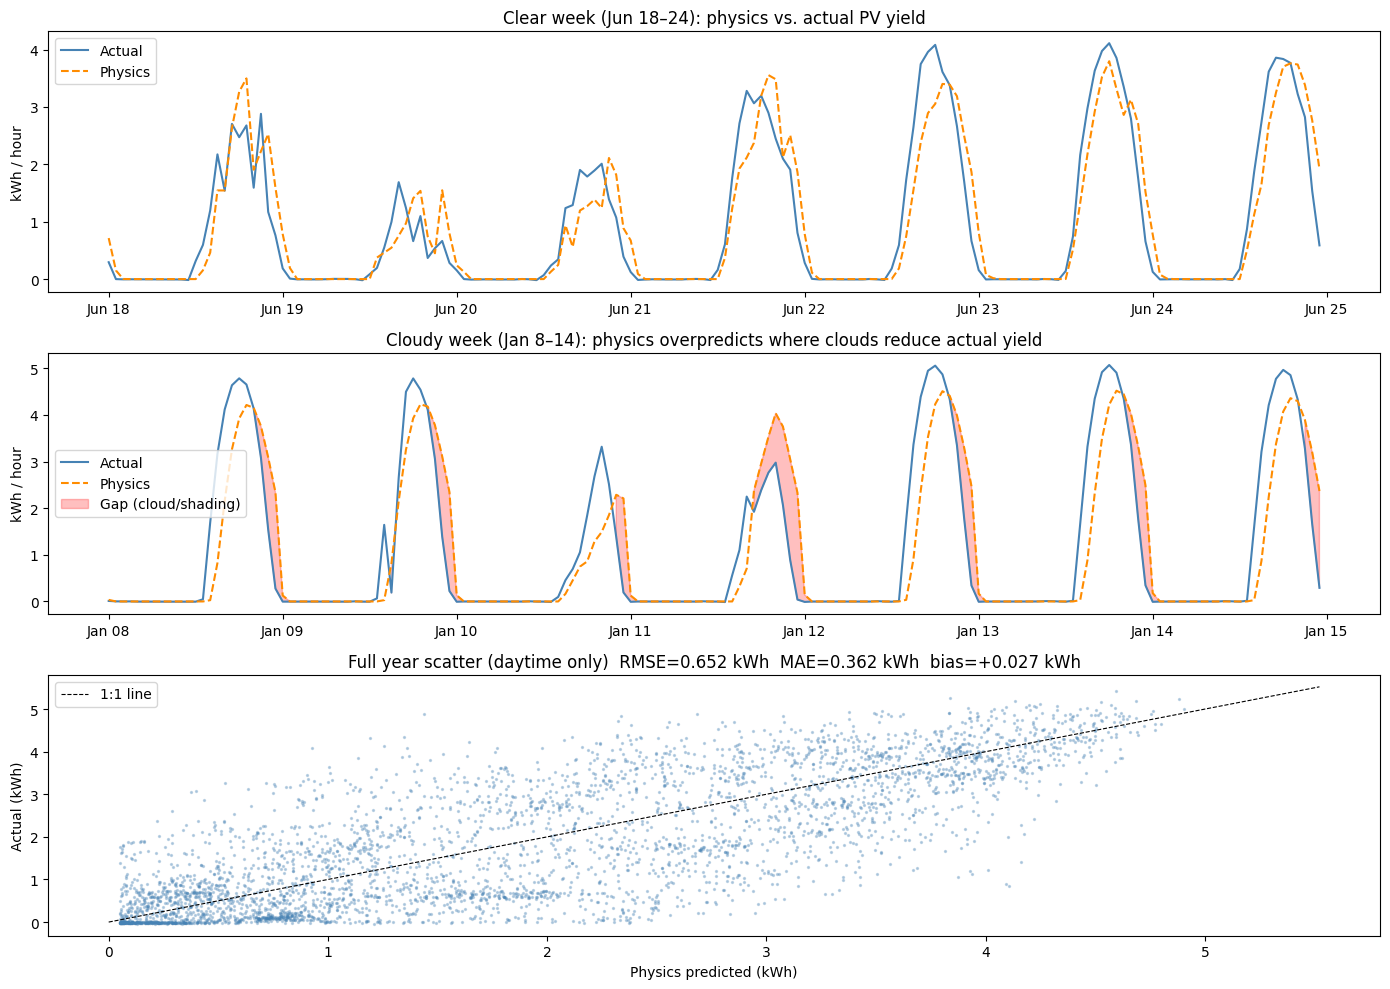

Plot saved to data/processed/physics_vs_actual.png


In [7]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

comp = unified[["actual_pv_yield_kwh", "physics_predicted_pv"]].dropna()
residual = comp["physics_predicted_pv"] - comp["actual_pv_yield_kwh"]

rmse = float(np.sqrt((residual ** 2).mean()))
mae  = float(residual.abs().mean())
bias = float(residual.mean())

print(f"n hours compared : {len(comp)}")
print(f"RMSE             : {rmse:.3f} kWh")
print(f"MAE              : {mae:.3f} kWh")
print(f"Mean bias        : {bias:+.3f} kWh  ({'physics overpredicts' if bias > 0 else 'physics underpredicts'})")

# ── Plot 1: one clear week (June 18-24) — physics should track actual closely
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

week = comp.loc["2018-06-18":"2018-06-24"]
ax = axes[0]
ax.plot(week.index, week["actual_pv_yield_kwh"],    label="Actual",  color="steelblue",  lw=1.5)
ax.plot(week.index, week["physics_predicted_pv"],   label="Physics", color="darkorange", lw=1.5, ls="--")
ax.set_title("Clear week (Jun 18–24): physics vs. actual PV yield")
ax.set_ylabel("kWh / hour")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

# ── Plot 2: one mixed/cloudy week (Jan 8-14) — physics should overpredict on bad days
week2 = comp.loc["2018-01-08":"2018-01-14"]
ax = axes[1]
ax.plot(week2.index, week2["actual_pv_yield_kwh"],   label="Actual",  color="steelblue",  lw=1.5)
ax.plot(week2.index, week2["physics_predicted_pv"],  label="Physics", color="darkorange", lw=1.5, ls="--")
ax.fill_between(
    week2.index,
    week2["actual_pv_yield_kwh"],
    week2["physics_predicted_pv"],
    where=week2["physics_predicted_pv"] > week2["actual_pv_yield_kwh"],
    alpha=0.25, color="red", label="Gap (cloud/shading)",
)
ax.set_title("Cloudy week (Jan 8–14): physics overpredicts where clouds reduce actual yield")
ax.set_ylabel("kWh / hour")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

# ── Plot 3: scatter — actual vs. predicted across the full year
daytime = comp[comp["physics_predicted_pv"] > 0.05]
ax = axes[2]
ax.scatter(daytime["physics_predicted_pv"], daytime["actual_pv_yield_kwh"],
           s=2, alpha=0.3, color="steelblue")
lim = max(daytime["physics_predicted_pv"].max(), daytime["actual_pv_yield_kwh"].max()) * 1.02
ax.plot([0, lim], [0, lim], "k--", lw=0.8, label="1:1 line")
ax.set_xlabel("Physics predicted (kWh)")
ax.set_ylabel("Actual (kWh)")
ax.set_title(f"Full year scatter (daytime only)  RMSE={rmse:.3f} kWh  MAE={mae:.3f} kWh  bias={bias:+.3f} kWh")
ax.legend(markerscale=4)

plt.tight_layout()
plt.savefig("../data/processed/physics_vs_actual.png", dpi=120)
plt.show()
print("Plot saved to data/processed/physics_vs_actual.png")